In [ ]:
!pip -q install -U datasets pandas matplotlib seaborn transformers accelerate trl

import json, re, random, textwrap
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, concatenate_datasets

random.seed(0)

CONFIG = "kimi"
ds = load_dataset("lambda/hermes-agent-reasoning-traces", CONFIG, split="train")
print(ds)
print("Config:", CONFIG, "| Fields:", ds.column_names)
print("Categories:", sorted(set(ds["category"])))

COMPARE_BOTH = False
if COMPARE_BOTH:
    ds_kimi = load_dataset("lambda/hermes-agent-reasoning-traces", "kimi", split="train")
    ds_glm  = load_dataset("lambda/hermes-agent-reasoning-traces", "glm-5.1", split="train")
    ds_kimi = ds_kimi.add_column("source", ["kimi"] * len(ds_kimi))
    ds_glm  = ds_glm.add_column("source", ["glm-5.1"] * len(ds_glm))
    ds = concatenate_datasets([ds_kimi, ds_glm]).shuffle(seed=0)
    print("Combined:", ds, "→ counts:", Counter(ds["source"]))

sample = ds[0]
print("\n=== Sample 0 ===")
print("id        :", sample["id"])
print("category  :", sample["category"], "/", sample["subcategory"])
print("task      :", sample["task"])
print("turns     :", len(sample["conversations"]))
print("system[0] :", sample["conversations"][0]["value"][:220], "...\n")

In [ ]:
THINK_RE     = re.compile(r"<think>(.*?)</think>", re.DOTALL)
TOOL_CALL_RE = re.compile(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", re.DOTALL)
TOOL_RESP_RE = re.compile(r"<tool_response>\s*(.*?)\s*</tool_response>", re.DOTALL)

def parse_assistant(value: str) -> dict:
    thoughts = [t.strip() for t in THINK_RE.findall(value)]
    calls = []
    for raw in TOOL_CALL_RE.findall(value):
        try:
            calls.append(json.loads(raw))
        except json.JSONDecodeError:
            calls.append({"name": "<malformed>", "arguments": {}})
    final = TOOL_CALL_RE.sub("", THINK_RE.sub("", value)).strip()
    return {"thoughts": thoughts, "tool_calls": calls, "final": final}

def parse_tool(value: str):
    raw = TOOL_RESP_RE.search(value)
    if not raw: return {"raw": value}
    body = raw.group(1)
    try:    return json.loads(body)
    except: return {"raw": body}

first_gpt = next(t for t in sample["conversations"] if t["from"] == "gpt")
p = parse_assistant(first_gpt["value"])
print("Thought preview :", (p["thoughts"][0][:160] + "...") if p["thoughts"] else "(none)")
print("Tool calls       :", [(c.get("name"), list(c.get("arguments", {}).keys())) for c in p["tool_calls"]])

In [ ]:
N = 3000
sub = ds.select(range(min(N, len(ds))))

tool_calls         = Counter()
parallel_widths    = Counter()
thoughts_per_turn  = []
calls_per_traj     = []
errors_per_traj    = []
turns_per_traj     = []
cat_counts         = Counter()

for ex in sub:
    cat_counts[ex["category"]] += 1
    n_calls = n_err = 0
    turns_per_traj.append(len(ex["conversations"]))
    for t in ex["conversations"]:
        if t["from"] == "gpt":
            p = parse_assistant(t["value"])
            thoughts_per_turn.append(len(p["thoughts"]))
            if p["tool_calls"]:
                parallel_widths[len(p["tool_calls"])] += 1
                for c in p["tool_calls"]:
                    tool_calls[c.get("name", "<unknown>")] += 1
                n_calls += len(p["tool_calls"])
        elif t["from"] == "tool":
            r = parse_tool(t["value"])
            blob = json.dumps(r).lower()
            if "error" in blob or '"exit_code": 1' in blob or "traceback" in blob:
                n_err += 1
    calls_per_traj.append(n_calls)
    errors_per_traj.append(n_err)

print(f"\nScanned {len(sub)} trajectories")
print(f"Avg turns/traj      : {np.mean(turns_per_traj):.1f}")
print(f"Avg tool calls/traj : {np.mean(calls_per_traj):.1f}")
print(f"% with >=1 error    : {100*np.mean([e>0 for e in errors_per_traj]):.1f}%")
print(f"% parallel turns    : {100*sum(v for k,v in parallel_widths.items() if k>1)/max(1,sum(parallel_widths.values())):.1f}%")
print("Top 10 tools        :", tool_calls.most_common(10))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

top = tool_calls.most_common(15)
axes[0,0].barh([t for t,_ in top][::-1], [c for _,c in top][::-1], color="teal")
axes[0,0].set_title("Top 15 tools by call volume")
axes[0,0].set_xlabel("calls")

ks = sorted(parallel_widths)
axes[0,1].bar([str(k) for k in ks], [parallel_widths[k] for k in ks], color="coral")
axes[0,1].set_title("Tool-calls per assistant turn (parallel width)")
axes[0,1].set_xlabel("# tool calls in one turn"); axes[0,1].set_ylabel("count")
axes[0,1].set_yscale("log")

axes[1,0].hist(turns_per_traj, bins=40, color="steelblue")
axes[1,0].set_title("Conversation length"); axes[1,0].set_xlabel("turns")

cats, vals = zip(*cat_counts.most_common())
axes[1,1].pie(vals, labels=cats, autopct="%1.0f%%", startangle=90)
axes[1,1].set_title("Category distribution")

plt.tight_layout(); plt.show()

In [ ]:
def render_trace(ex, max_chars=350):
    print(f"\n{'='*72}\nTASK [{ex['category']} / {ex['subcategory']}]: {ex['task']}\n{'='*72}")
    for t in ex["conversations"]:
        role = t["from"]
        if role == "system":
            continue
        if role == "human":
            print(f"\n[USER]\n{textwrap.shorten(t['value'], 600)}")
        elif role == "gpt":
            p = parse_assistant(t["value"])
            for th in p["thoughts"]:
                print(f"\n[THINK]\n{textwrap.shorten(th, max_chars)}")
            for c in p["tool_calls"]:
                args = json.dumps(c.get("arguments", {}))[:200]
                print(f"[CALL] {c.get('name')}({args})")
            if p["final"]:
                print(f"\n[ANSWER]\n{textwrap.shorten(p['final'], max_chars)}")
        elif role == "tool":
            print(f"[TOOL_RESPONSE] {textwrap.shorten(t['value'], 220)}")
    print("="*72)

idx = int(np.argmin(np.abs(np.array(turns_per_traj) - 10)))
render_trace(sub[idx])

def get_tool_schemas(ex):
    try:    return json.loads(ex["tools"])
    except: return []

schemas = get_tool_schemas(sample)
print(f"\nSample 0 has {len(schemas)} tools available")
for s in schemas[:3]:
    fn = s.get("function", {})
    print(" -", fn.get("name"), "—", (fn.get("description") or "")[:80])

ROLE_MAP = {"system": "system", "human": "user", "gpt": "assistant", "tool": "tool"}

def to_openai_messages(conv):
    return [{"role": ROLE_MAP[t["from"]], "content": t["value"]} for t in conv]

example_msgs = to_openai_messages(sample["conversations"])
print("\nFirst 2 OpenAI messages:")
for m in example_msgs[:2]:
    print(" ", m["role"], "→", m["content"][:120].replace("\n", " "), "...")

data/kimi/train.parquet:   0%|          | 0.00/508M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7646 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'conversations', 'tools', 'category', 'subcategory', 'task'],
    num_rows: 7646
})
Config: kimi | Fields: ['id', 'conversations', 'tools', 'category', 'subcategory', 'task']
Categories: ['Agent Tools', 'Browser Automation', 'Conversational', 'File Operations', 'Multi-Tool', 'Planning & Organization', 'Repository Tasks', 'Scheduling', 'Terminal & Coding']

=== Sample 0 ===
id        : 0c699abf-bc77-454a-8197-d56a2294098a
category  : Agent Tools / Memory & Context
task      : Look through past sessions for the deployment config we created for the staging environment
turns     : 13
system[0] : You are a function calling AI model. You are provided with function signatures within <tools> </tools> XML tags. You may call one or more functions to assist with the user query. If available tools are not relevant in as ...

Thought preview : The user wants me to look through past sessions for a deployment config for a staging environment. I should use the session_se

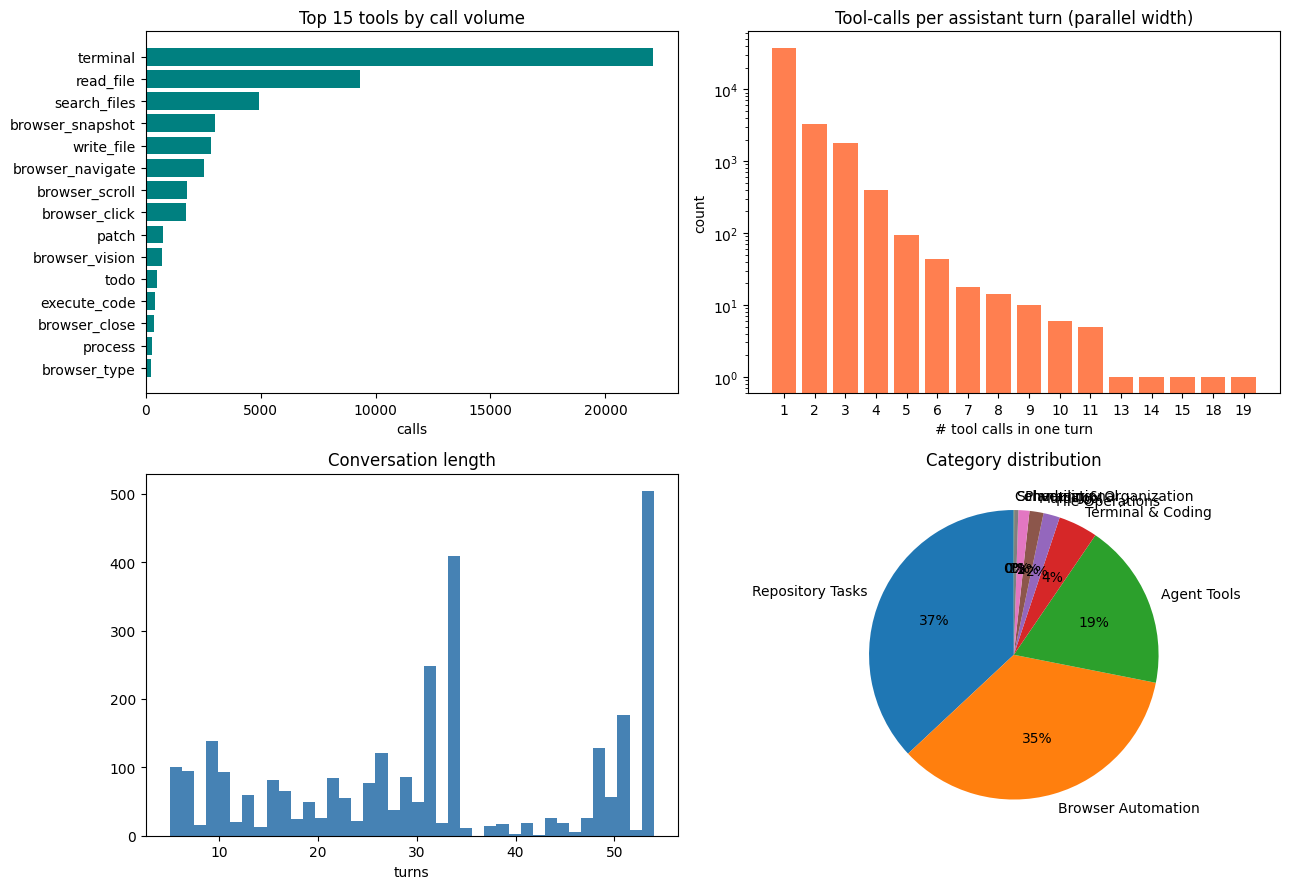


TASK [Agent Tools / Session & Memory]: Find the debugging steps we used last time for the connection timeout issue

[USER]
Find the debugging steps we used last time for the connection timeout issue. I'm seeing a similar issue now: growing memory usage in the worker.

[THINK]
The user is asking about debugging steps from a previous session related to a connection timeout issue. They mentioned they're seeing a similar issue now with growing memory usage in the worker. I should search through past sessions to find this information. Let me use session_search to find the relevant debugging steps. I'll search for terms [...]
[CALL] session_search({"query": "debugging connection timeout memory worker"})
[TOOL_RESPONSE] <tool_response> {"tool_call_id": "functions.session_search:0", "name": "session_search", "content": {"success": false, "error": "Session database not available."}} </tool_response>

[THINK]
The session search failed. Let me try a different search query or approach to find pas

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenized example: 2048 tokens, 0 trainable (0.0%)


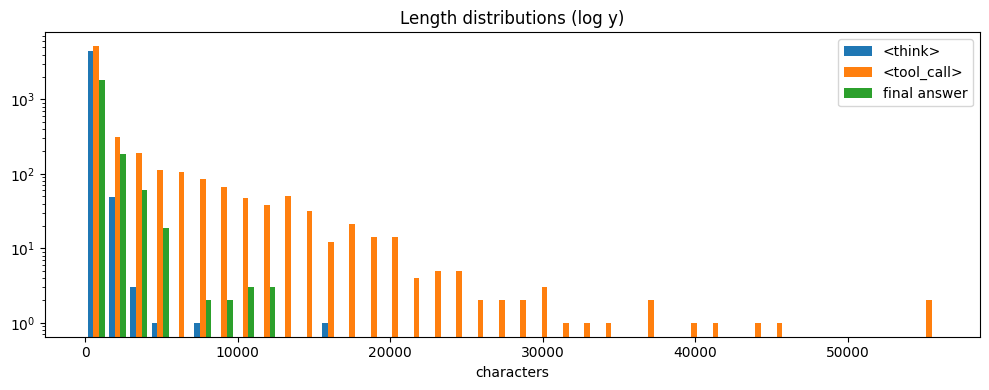


── Step 1/6 ──
💭 The user wants me to look through past sessions for a deployment config for a staging environment. I should use the session_search tool to find this. Let me search for relevant keywords like "staging", "deployment", "config" to find the session where they created this.
⚙️  session_search({"query": "staging deployment config"})
📥 {"tool_call_id": "functions.session_search:0", "name": "session_search", "content": {"success": false, "error": "Session database not available."}}

── Step 2/6 ──
💭 It looks like the session search is not available. Let me try another search query in case that helps, or let the user know I can't access the past sessions.
⚙️  session_search({"query": "deploy staging"})
⚙️  session_search({"query": "environment configuration"})
📥 {"tool_call_id": "functions.session_search:1", "name": "session_search", "content": {"success": false, "error": "Session database not available."}}
💬 I don't currently have access to the session database to search thro

In [2]:
from transformers import AutoTokenizer
TOK_ID = "Qwen/Qwen2.5-0.5B-Instruct"
tok = AutoTokenizer.from_pretrained(TOK_ID)

def build_masked(conv, tokenizer, max_len=2048):
    msgs = to_openai_messages(conv)
    for m in msgs:
        if m["role"] == "tool":
            m["role"] = "user"
            m["content"] = "[TOOL OUTPUT]\n" + m["content"]
    input_ids, labels = [], []
    for m in msgs:
        text = tokenizer.apply_chat_template([m], tokenize=False, add_generation_prompt=False)
        ids = tokenizer.encode(text, add_special_tokens=False)
        input_ids.extend(ids)
        labels.extend(ids if m["role"] == "assistant" else [-100] * len(ids))
    return input_ids[:max_len], labels[:max_len]

ids, lbls = build_masked(sample["conversations"], tok)
trainable = sum(1 for x in lbls if x != -100)
print(f"\nTokenized example: {len(ids)} tokens, {trainable} trainable ({100*trainable/len(ids):.1f}%)")

think_lens, call_lens, ans_lens = [], [], []
for ex in sub.select(range(min(500, len(sub)))):
    for t in ex["conversations"]:
        if t["from"] != "gpt": continue
        p = parse_assistant(t["value"])
        for th in p["thoughts"]: think_lens.append(len(th))
        for c in p["tool_calls"]: call_lens.append(len(json.dumps(c)))
        if p["final"]: ans_lens.append(len(p["final"]))

plt.figure(figsize=(10,4))
plt.hist([think_lens, call_lens, ans_lens], bins=40, log=True,
         label=["<think>", "<tool_call>", "final answer"], stacked=False)
plt.legend(); plt.xlabel("characters"); plt.title("Length distributions (log y)")
plt.tight_layout(); plt.show()

class TraceReplayer:
    def __init__(self, ex):
        self.ex = ex
        self.steps = []
        pending = None
        for t in ex["conversations"]:
            if t["from"] == "gpt":
                if pending: self.steps.append(pending)
                pending = {"think": parse_assistant(t["value"]), "responses": []}
            elif t["from"] == "tool" and pending:
                pending["responses"].append(parse_tool(t["value"]))
        if pending: self.steps.append(pending)
    def __len__(self): return len(self.steps)
    def play(self, i):
        s = self.steps[i]
        print(f"\n── Step {i+1}/{len(self)} ──")
        for th in s["think"]["thoughts"]:
            print(f"💭 {textwrap.shorten(th, 280)}")
        for c in s["think"]["tool_calls"]:
            print(f"⚙️  {c.get('name')}({json.dumps(c.get('arguments', {}))[:140]})")
        for r in s["responses"]:
            print(f"📥 {textwrap.shorten(json.dumps(r), 200)}")
        if s["think"]["final"]:
            print(f"💬 {textwrap.shorten(s['think']['final'], 200)}")

rp = TraceReplayer(sample)
for i in range(min(3, len(rp))):
    rp.play(i)

TRAIN = False
if TRAIN:
    import torch
    from transformers import AutoModelForCausalLM
    from trl import SFTTrainer, SFTConfig

    train_subset = ds.select(range(200))

    def to_text(batch):
        msgs = to_openai_messages(batch["conversations"])
        for m in msgs:
            if m["role"] == "tool":
                m["role"] = "user"; m["content"] = "[TOOL]\n" + m["content"]
        batch["text"] = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        return batch

    train_subset = train_subset.map(to_text)

    model = AutoModelForCausalLM.from_pretrained(
        TOK_ID,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
    )

    cfg = SFTConfig(
        output_dir="hermes-sft-demo",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        max_steps=20,
        learning_rate=2e-5,
        logging_steps=2,
        max_seq_length=1024,
        dataset_text_field="text",
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    SFTTrainer(model=model, args=cfg, train_dataset=train_subset, processing_class=tok).train()
    print("Fine-tune demo finished.")

print("\n✅ Tutorial complete. You now have parsers, analytics, plots, a replayer, "
      "tokenized + label-masked SFT examples, and an optional training hook.")